In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ==========================================================
# Project paths
# ==========================================================

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

DATA_DIR = PROJECT_ROOT / "data" / "arima"

RESULTS_DIR = PROJECT_ROOT / "results" / "simulations"
FIGURES_DIR = PROJECT_ROOT / "figures" / "monte_carlo"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# ==========================================================
# Asset configuration
# ==========================================================

ASSETS = {
    "TSLA": {
        "file": "TSLA_arima.csv",
        "asset_class": "equity"
    },

    "GOOGL": {
        "file": "GOOGL_arima.csv",
        "asset_class": "equity"
    },

    "BTCUSD": {
        "file": "BTCUSD_arima.csv",
        "asset_class": "crypto"
    },

    "ETHUSD": {
        "file": "ETHUSD_arima.csv",
        "asset_class": "crypto"
    }
}


# ==========================================================
# Simulation settings
# ==========================================================

N_SIMULATIONS = 10_000
N_SAMPLE_PATHS = 100
LOOKBACK_YEARS = 3
RANDOM_SEED = 42


# Equity uses trading observations.
# Crypto trades continuously.

HORIZON_STEPS = {
    "equity": {
        "30D": 21,
        "3M": 63,
        "6M": 126,
        "1Y": 252
    },

    "crypto": {
        "30D": 30,
        "3M": 91,
        "6M": 182,
        "1Y": 365
    }
}

In [3]:
LOOKBACK_YEARS = 3

In [4]:
def load_asset_data(file_path):
    """
    Load and clean asset price data.
    """

    df = pd.read_csv(file_path)

    df["Date"] = pd.to_datetime(
        df["Date"]
    )

    df = (
        df
        .sort_values("Date")
        .reset_index(drop=True)
    )

    return df

In [5]:
def estimate_mc_parameters(
    df,
    lookback_years=3
):
    """
    Estimate current price, mean daily log return,
    and daily volatility using a recent historical window.
    """

    end_date = df["Date"].max()

    start_date = (
        end_date
        - pd.DateOffset(
            years=lookback_years
        )
    )

    sample = (
        df[
            df["Date"] >= start_date
        ]
        .copy()
    )

    log_returns = np.log(
        sample["Close"]
        / sample["Close"].shift(1)
    ).dropna()

    current_price = (
        sample["Close"].iloc[-1]
    )

    mu_daily = (
        log_returns.mean()
    )

    sigma_daily = (
        log_returns.std()
    )

    return {
        "Current_Price": current_price,
        "Mu_Daily": mu_daily,
        "Sigma_Daily": sigma_daily,
        "Sample_Start": sample["Date"].min(),
        "Sample_End": sample["Date"].max(),
        "Observations": len(log_returns)
    }

In [6]:
def simulate_terminal_prices(
    current_price,
    mu_daily,
    sigma_daily,
    steps,
    n_simulations,
    rng
):
    """
    Efficiently simulate terminal prices
    without storing full price paths.
    """

    z = rng.standard_normal(
        n_simulations
    )

    cumulative_log_return = (
        mu_daily * steps
        +
        sigma_daily
        * np.sqrt(steps)
        * z
    )

    terminal_prices = (
        current_price
        * np.exp(
            cumulative_log_return
        )
    )

    return terminal_prices

In [7]:
def simulate_sample_paths(
    current_price,
    mu_daily,
    sigma_daily,
    steps,
    n_paths,
    rng
):
    """
    Generate a small number of complete price paths
    for visualization.
    """

    shocks = rng.normal(
        loc=mu_daily,
        scale=sigma_daily,
        size=(steps, n_paths)
    )

    cumulative_returns = np.cumsum(
        shocks,
        axis=0
    )

    price_paths = (
        current_price
        * np.exp(
            cumulative_returns
        )
    )

    # Add starting price
    starting_row = np.full(
        (1, n_paths),
        current_price
    )

    price_paths = np.vstack([
        starting_row,
        price_paths
    ])

    return price_paths

In [8]:
def summarize_terminal_prices(
    terminal_prices,
    current_price
):
    """
    Summarize the simulated future price distribution.
    """

    p10 = np.percentile(
        terminal_prices,
        10
    )

    p25 = np.percentile(
        terminal_prices,
        25
    )

    median = np.percentile(
        terminal_prices,
        50
    )

    p75 = np.percentile(
        terminal_prices,
        75
    )

    p90 = np.percentile(
        terminal_prices,
        90
    )

    mean_price = np.mean(
        terminal_prices
    )

    prob_above_current = np.mean(
        terminal_prices
        > current_price
    )

    return {
        "P10_Price": p10,
        "P25_Price": p25,
        "Median_Price": median,
        "Mean_Price": mean_price,
        "P75_Price": p75,
        "P90_Price": p90,

        "P10_Return": (
            p10 / current_price - 1
        ),

        "Median_Return": (
            median / current_price - 1
        ),

        "P90_Return": (
            p90 / current_price - 1
        ),

        "Probability_Above_Current": (
            prob_above_current
        )
    }

In [9]:
def plot_sample_paths(
    paths,
    asset,
    horizon,
    save_path
):
    plt.figure(
        figsize=(11, 6)
    )

    plt.plot(
        paths,
        alpha=0.25,
        linewidth=0.8
    )

    plt.title(
        f"{asset} Monte Carlo Simulated Price Paths - {horizon}"
    )

    plt.xlabel(
        "Future Observations"
    )

    plt.ylabel(
        "Price"
    )

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [10]:
def plot_terminal_distribution(
    terminal_prices,
    asset,
    horizon,
    current_price,
    save_path
):
    p10 = np.percentile(
        terminal_prices,
        10
    )

    median = np.percentile(
        terminal_prices,
        50
    )

    p90 = np.percentile(
        terminal_prices,
        90
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.hist(
        terminal_prices,
        bins=80,
        alpha=0.8
    )

    plt.axvline(
        p10,
        linestyle="--",
        label="P10"
    )

    plt.axvline(
        median,
        linestyle="--",
        label="Median"
    )

    plt.axvline(
        p90,
        linestyle="--",
        label="P90"
    )

    plt.axvline(
        current_price,
        linestyle=":",
        label="Current Price"
    )

    plt.title(
        f"{asset} Monte Carlo Terminal Price Distribution - {horizon}"
    )

    plt.xlabel(
        "Future Price"
    )

    plt.ylabel(
        "Frequency"
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [11]:
def run_monte_carlo_asset(
    asset,
    config,
    horizons,
    n_simulations=10_000,
    n_sample_paths=100,
    lookback_years=3,
    seed=42
):
    """
    Run complete Monte Carlo simulation
    for one asset across multiple horizons.
    """

    print(
        f"\n{'=' * 60}"
    )

    print(
        f"Running Monte Carlo for {asset}"
    )

    print(
        f"{'=' * 60}"
    )

    # ------------------------------------------------------
    # Load data
    # ------------------------------------------------------

    file_path = (
        DATA_DIR
        / config["file"]
    )

    df = load_asset_data(
        file_path
    )

    asset_class = (
        config["asset_class"]
    )

    # ------------------------------------------------------
    # Estimate parameters
    # ------------------------------------------------------

    params = estimate_mc_parameters(
        df,
        lookback_years=lookback_years
    )

    current_price = (
        params["Current_Price"]
    )

    mu_daily = (
        params["Mu_Daily"]
    )

    sigma_daily = (
        params["Sigma_Daily"]
    )

    # Annualization only for reporting
    observations_per_year = (
        252
        if asset_class == "equity"
        else 365
    )

    annualized_log_return = (
        mu_daily
        * observations_per_year
    )

    annualized_volatility = (
        sigma_daily
        * np.sqrt(
            observations_per_year
        )
    )

    print(
        "Current Price:",
        round(current_price, 2)
    )

    print(
        "Daily Mean Log Return:",
        round(mu_daily, 6)
    )

    print(
        "Daily Volatility:",
        round(sigma_daily, 6)
    )

    print(
        "Annualized Volatility:",
        round(
            annualized_volatility * 100,
            2
        ),
        "%"
    )

    # ------------------------------------------------------
    # Output folders
    # ------------------------------------------------------

    asset_result_dir = (
        RESULTS_DIR / asset
    )

    asset_figure_dir = (
        FIGURES_DIR / asset
    )

    asset_result_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    asset_figure_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    # ------------------------------------------------------
    # Random number generator
    # ------------------------------------------------------

    rng = np.random.default_rng(
        seed
    )

    asset_results = []

    # ------------------------------------------------------
    # Run each horizon
    # ------------------------------------------------------

    for horizon in horizons:

        steps = (
            HORIZON_STEPS[
                asset_class
            ][horizon]
        )

        print(
            f"\nRunning {horizon} "
            f"({steps} observations)..."
        )

        # Terminal simulations
        terminal_prices = (
            simulate_terminal_prices(
                current_price=current_price,
                mu_daily=mu_daily,
                sigma_daily=sigma_daily,
                steps=steps,
                n_simulations=n_simulations,
                rng=rng
            )
        )

        # Summary
        summary = (
            summarize_terminal_prices(
                terminal_prices,
                current_price
            )
        )

        summary.update({
            "Asset": asset,
            "Asset_Class": asset_class,
            "Horizon": horizon,
            "Steps": steps,
            "Current_Price": current_price,

            "Mu_Daily": mu_daily,
            "Sigma_Daily": sigma_daily,

            "Annualized_Log_Return": (
                annualized_log_return
            ),

            "Annualized_Volatility": (
                annualized_volatility
            ),

            "Lookback_Years": (
                lookback_years
            ),

            "Historical_Observations": (
                params["Observations"]
            ),

            "N_Simulations": (
                n_simulations
            )
        })

        asset_results.append(
            summary
        )

        # --------------------------------------------------
        # Save terminal distribution
        # --------------------------------------------------

        terminal_df = pd.DataFrame({
            "Terminal_Price": terminal_prices
        })

        terminal_df.to_csv(
            asset_result_dir
            / f"{asset}_MC_{horizon}_terminal_prices.csv",
            index=False
        )

        # --------------------------------------------------
        # Sample paths
        # --------------------------------------------------

        sample_paths = (
            simulate_sample_paths(
                current_price=current_price,
                mu_daily=mu_daily,
                sigma_daily=sigma_daily,
                steps=steps,
                n_paths=n_sample_paths,
                rng=rng
            )
        )

        plot_sample_paths(
            paths=sample_paths,
            asset=asset,
            horizon=horizon,
            save_path=(
                asset_figure_dir
                / f"{asset}_MC_{horizon}_paths.png"
            )
        )

        # --------------------------------------------------
        # Terminal distribution plot
        # --------------------------------------------------

        plot_terminal_distribution(
            terminal_prices=terminal_prices,
            asset=asset,
            horizon=horizon,
            current_price=current_price,
            save_path=(
                asset_figure_dir
                / f"{asset}_MC_{horizon}_distribution.png"
            )
        )

        print(
            f"{horizon} completed."
        )

    return pd.DataFrame(
        asset_results
    )


Running Monte Carlo for TSLA
Current Price: 350.25
Daily Mean Log Return: 0.000511
Daily Volatility: 0.036561
Annualized Volatility: 58.04 %

Running 30D (21 observations)...


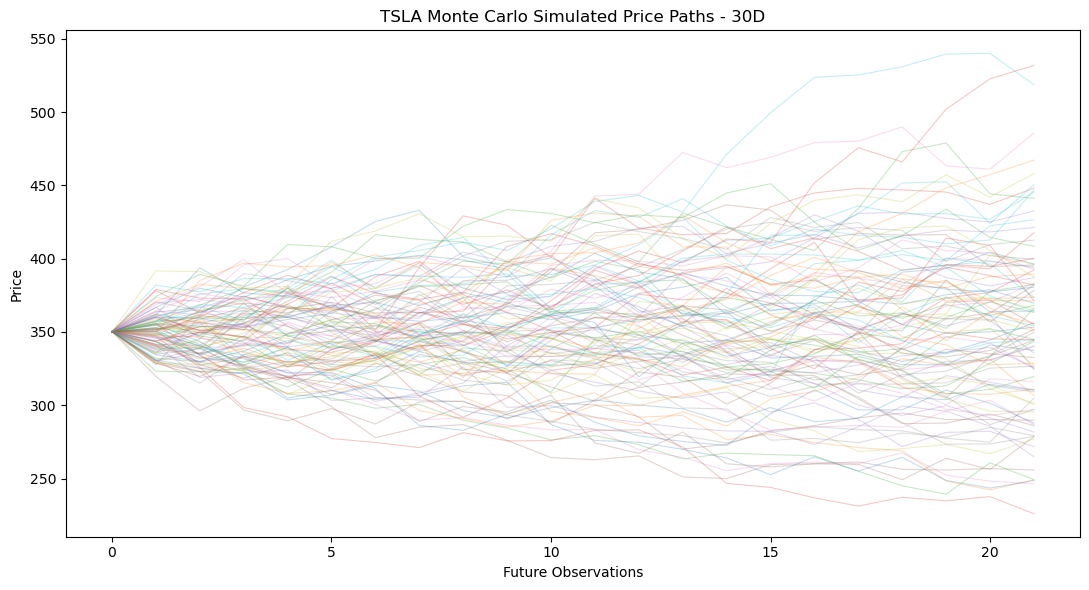

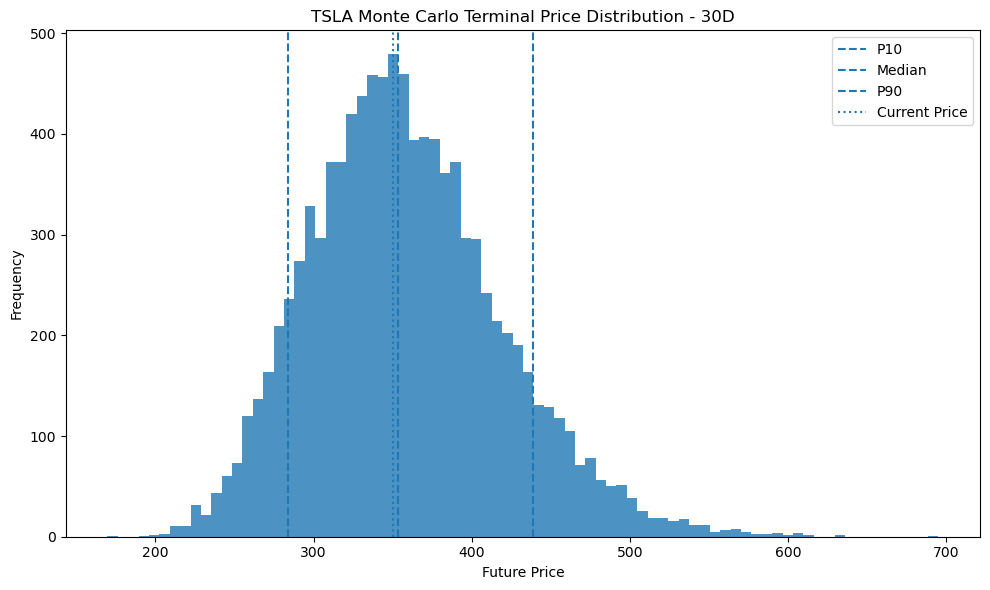

30D completed.

Running 3M (63 observations)...


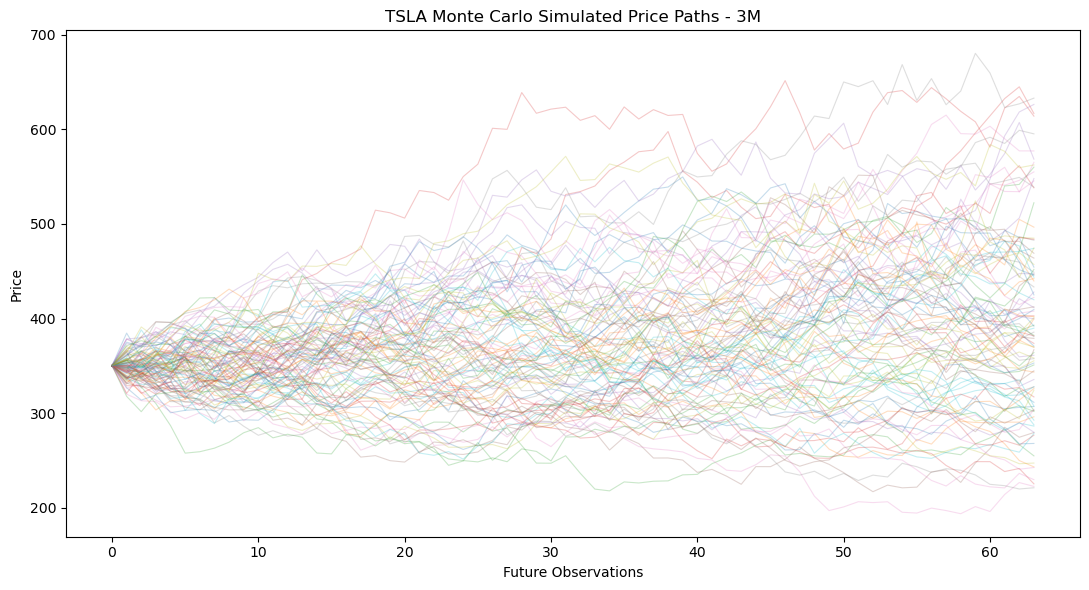

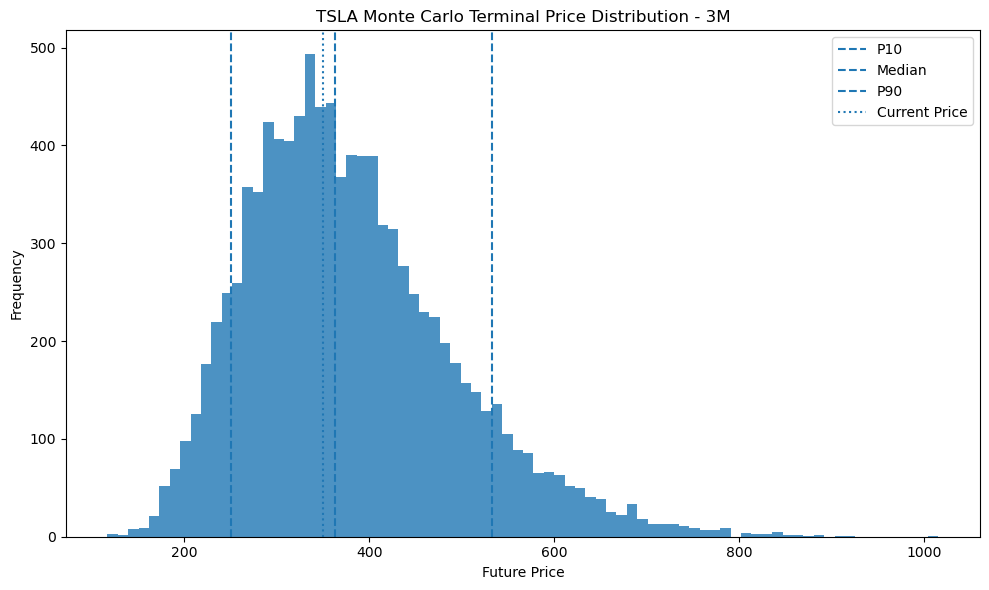

3M completed.

Running 6M (126 observations)...


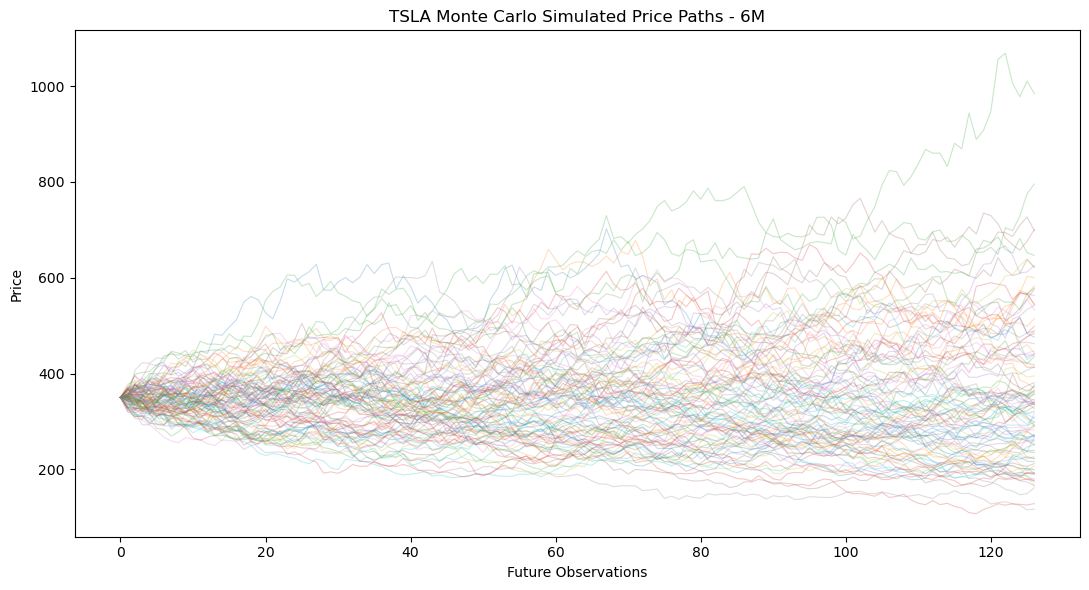

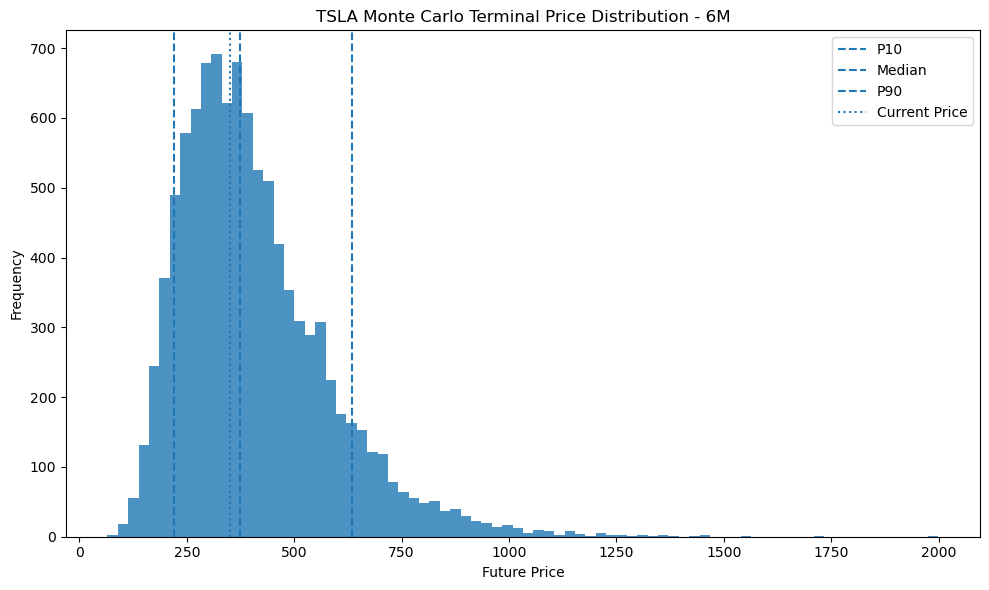

6M completed.

Running 1Y (252 observations)...


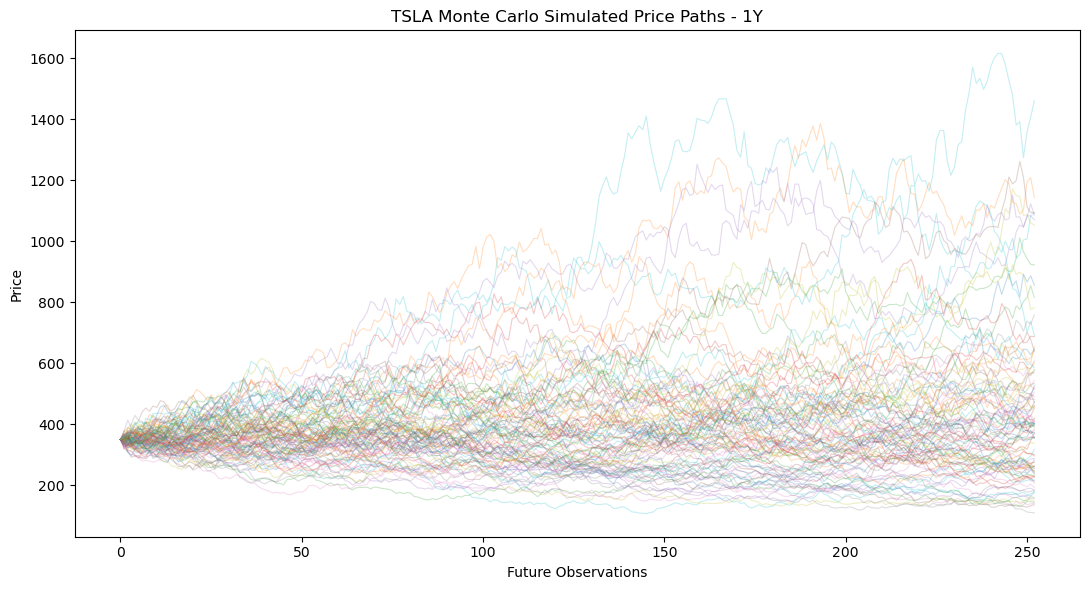

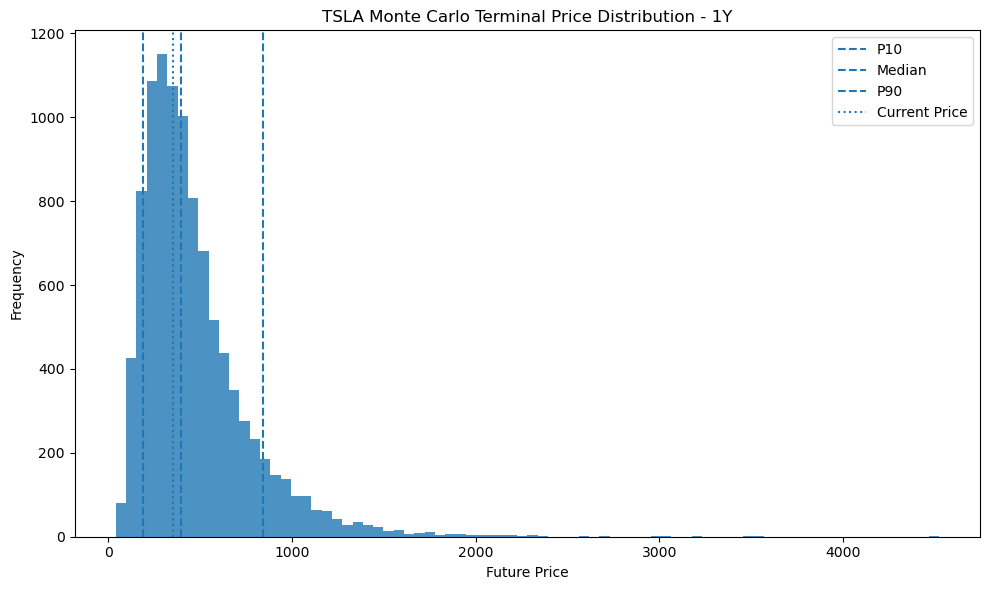

1Y completed.

Running Monte Carlo for GOOGL
Current Price: 346.96
Daily Mean Log Return: 0.001313
Daily Volatility: 0.019215
Annualized Volatility: 30.5 %

Running 30D (21 observations)...


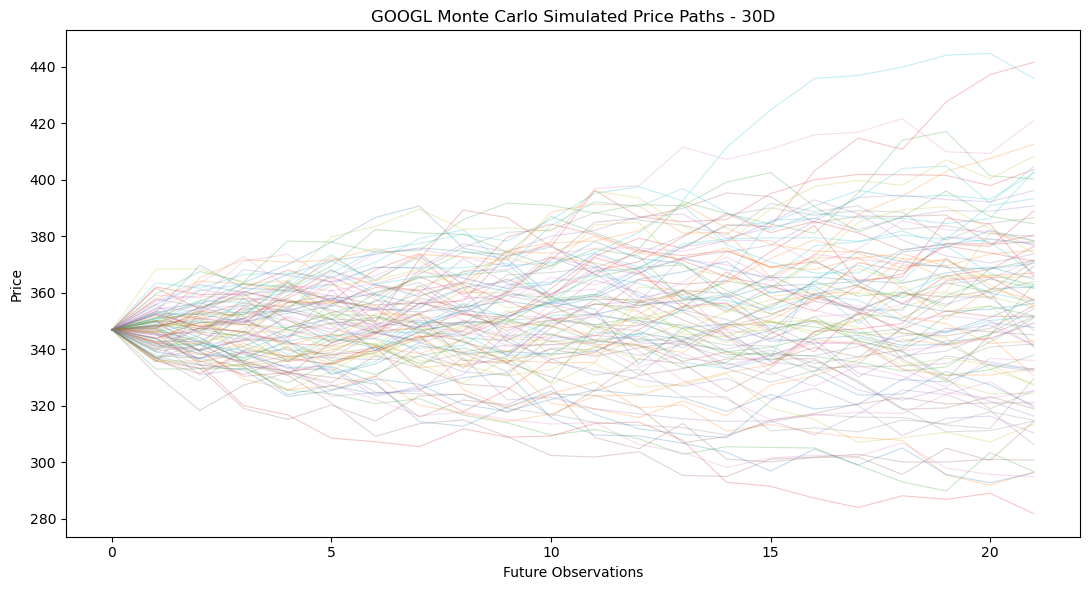

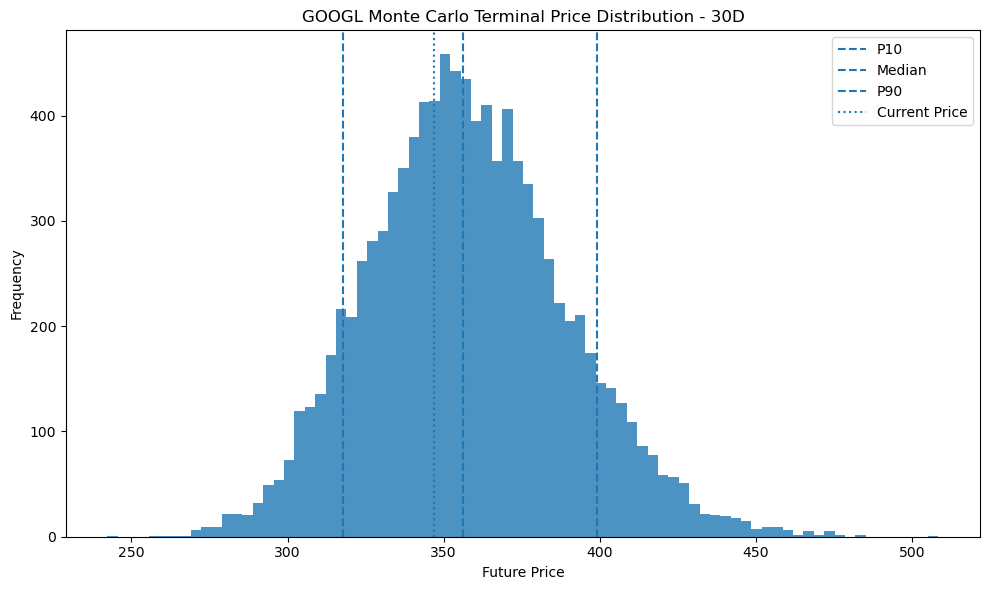

30D completed.

Running 3M (63 observations)...


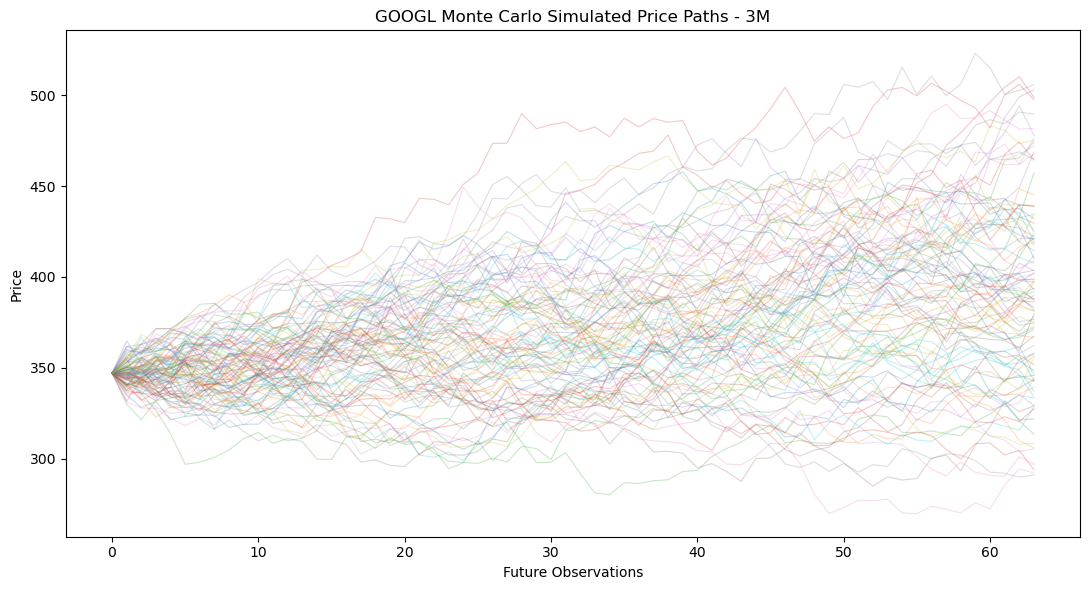

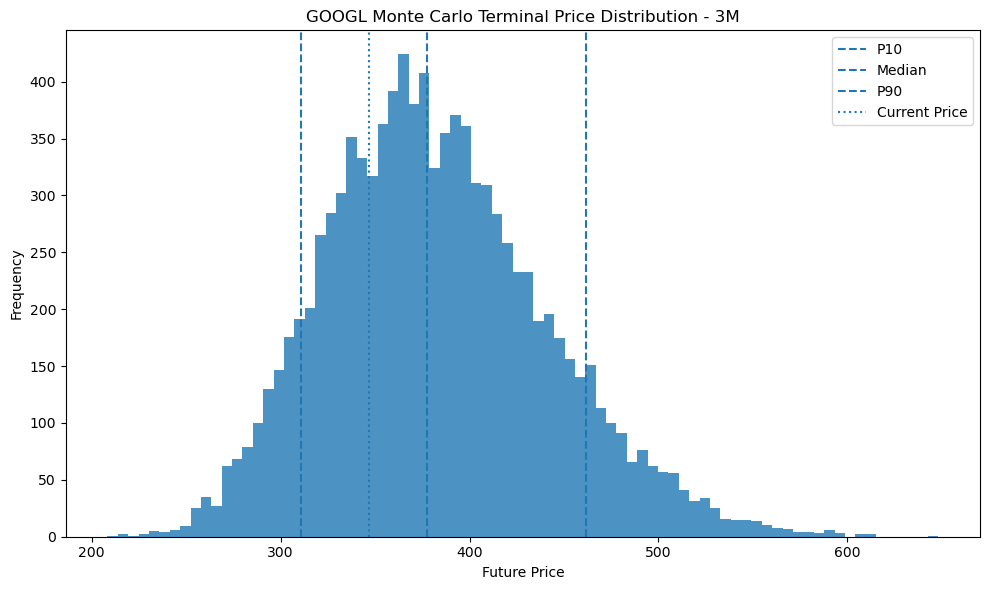

3M completed.

Running 6M (126 observations)...


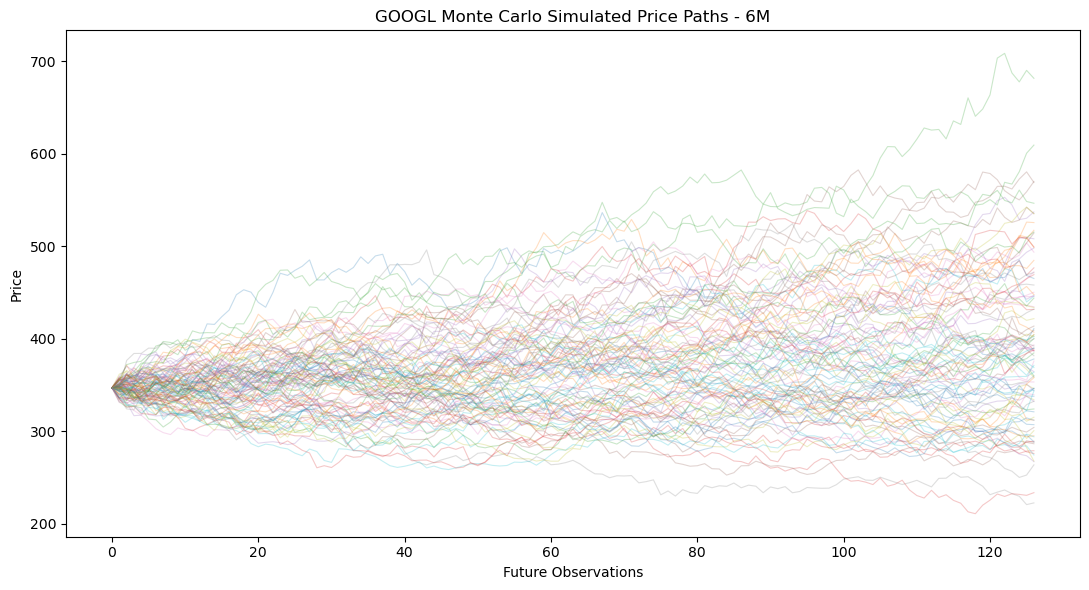

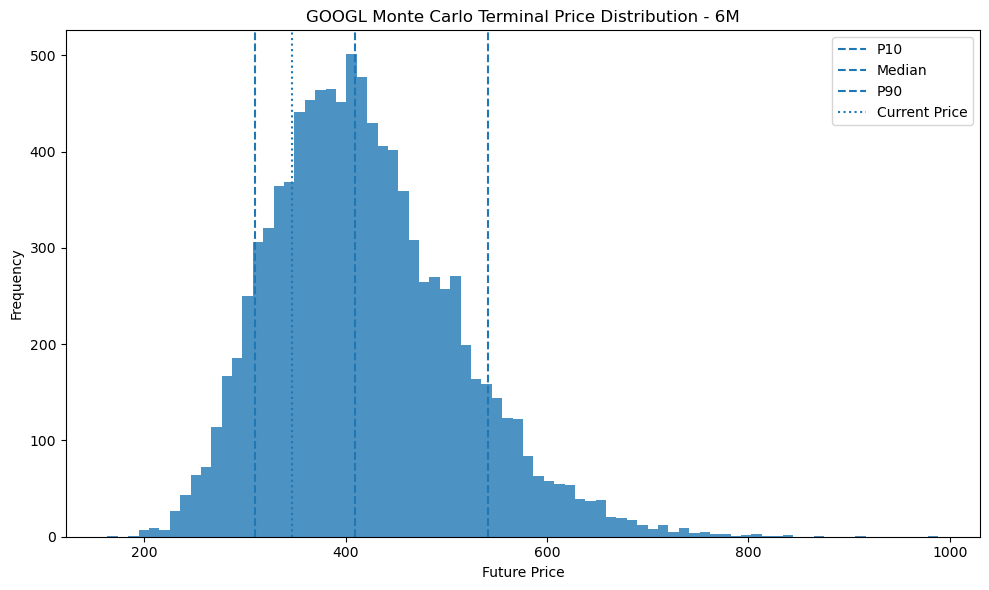

6M completed.

Running 1Y (252 observations)...


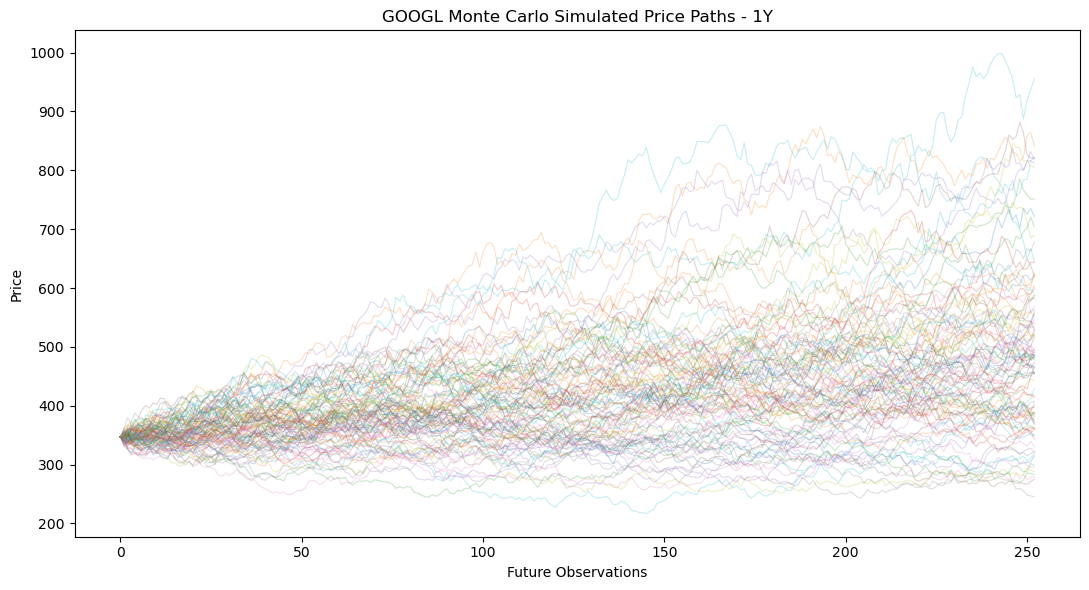

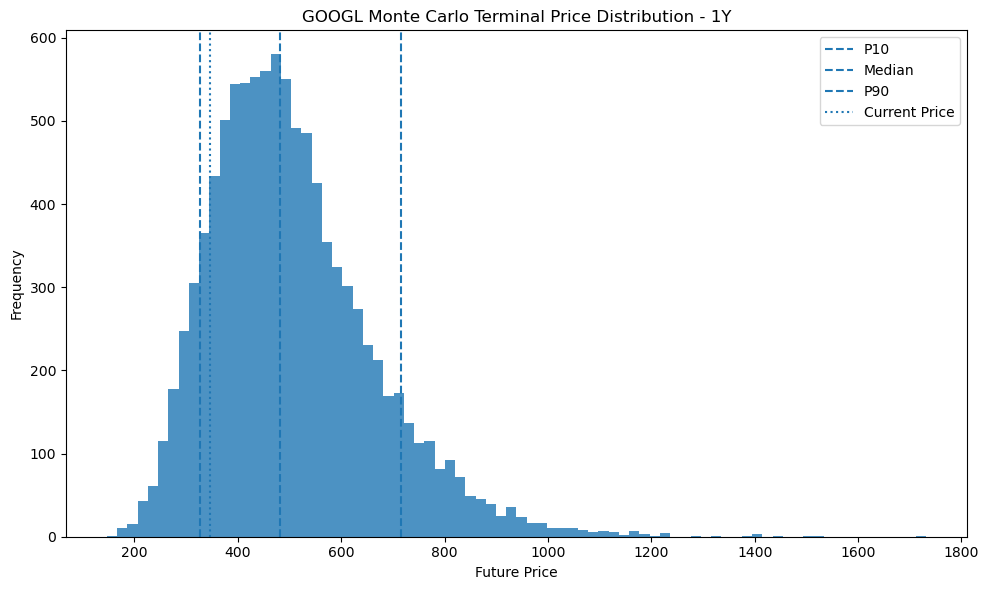

1Y completed.

Running Monte Carlo for BTCUSD
Current Price: 78274.2
Daily Mean Log Return: 0.001425
Daily Volatility: 0.028734
Annualized Volatility: 54.9 %

Running 30D (30 observations)...


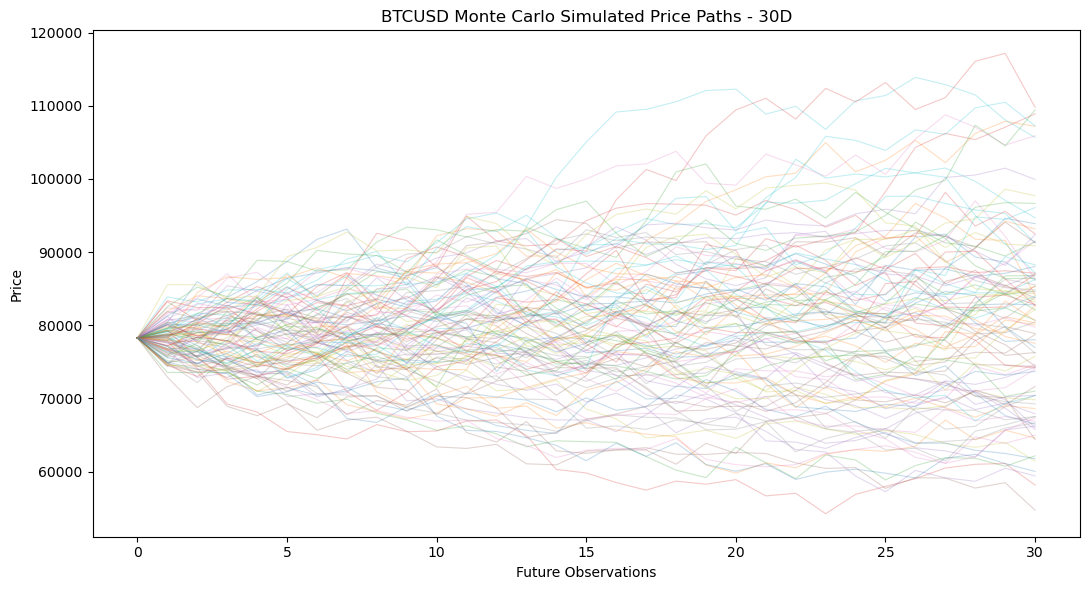

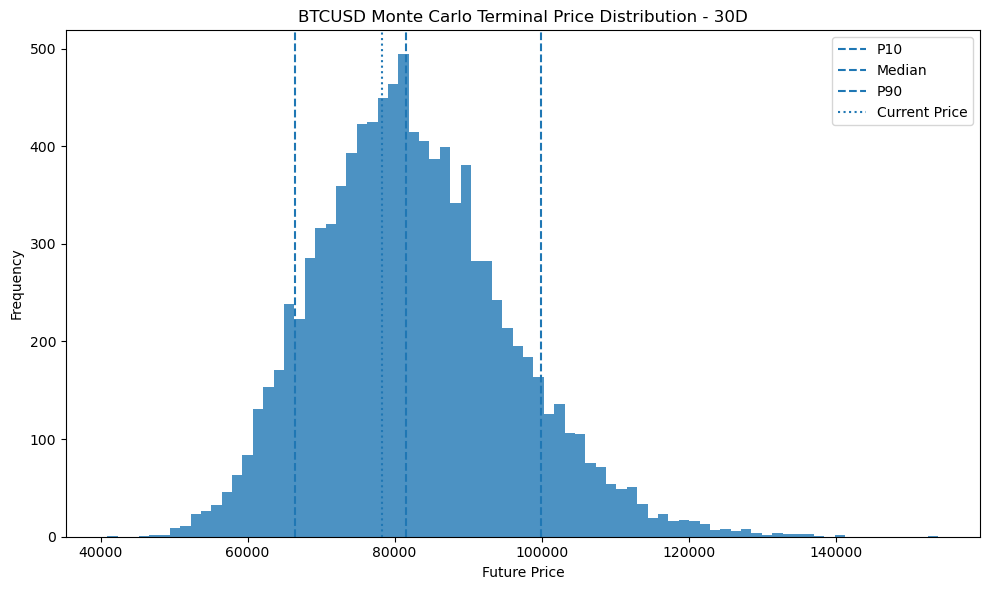

30D completed.

Running 3M (91 observations)...


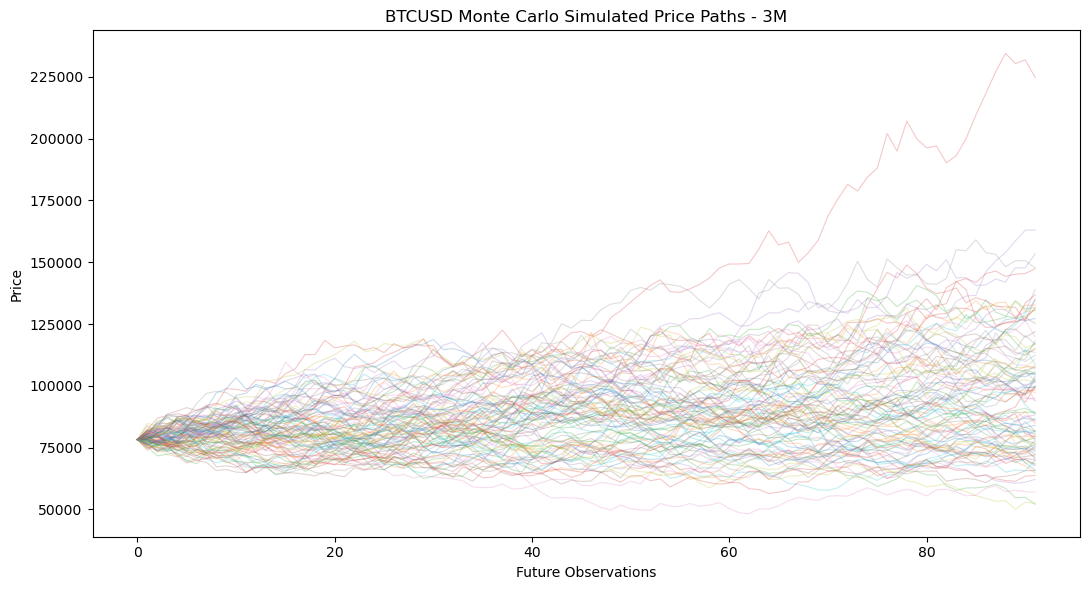

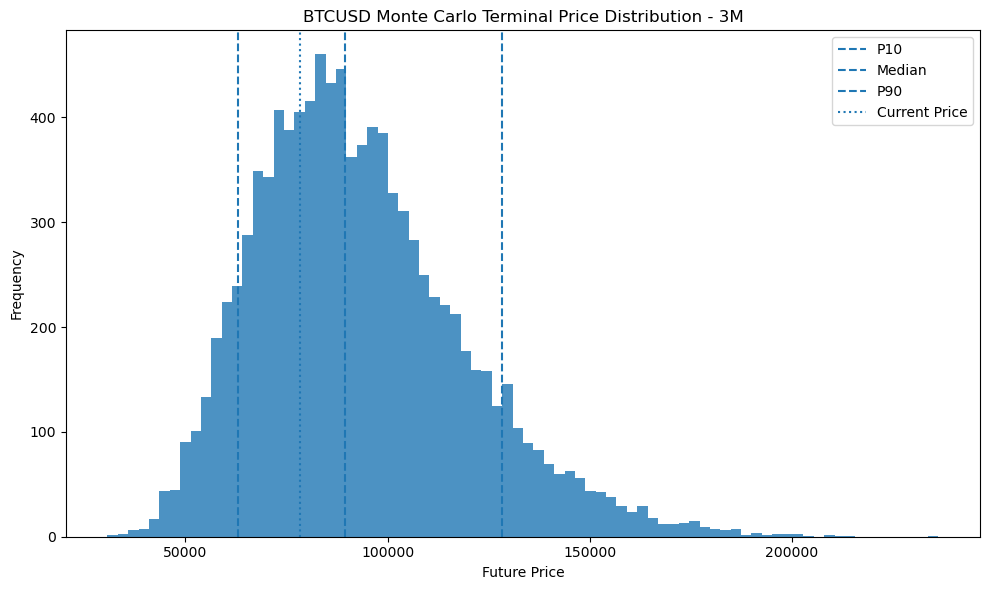

3M completed.

Running 6M (182 observations)...


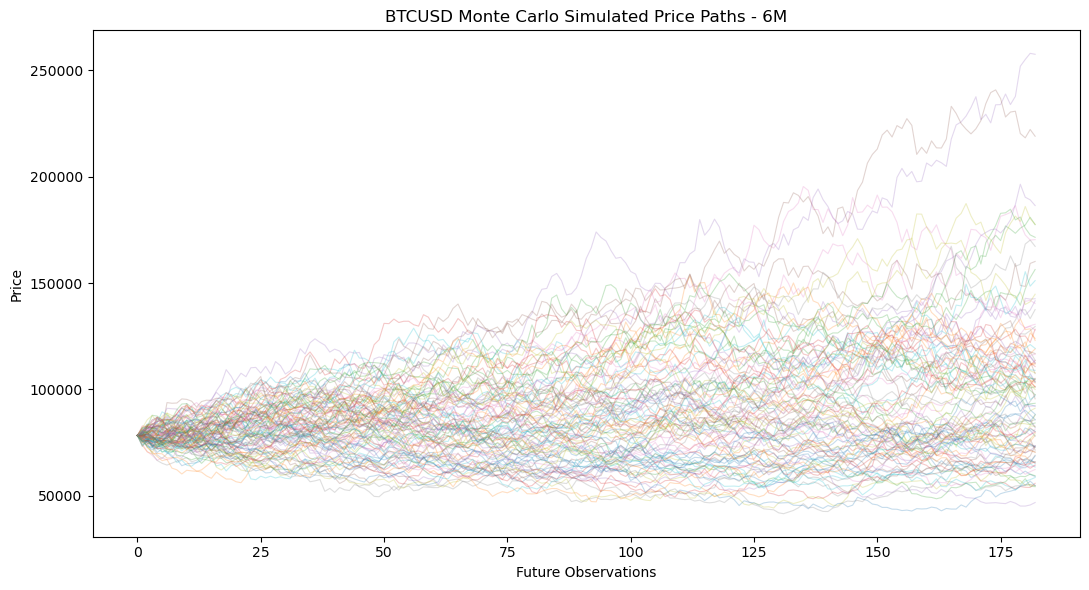

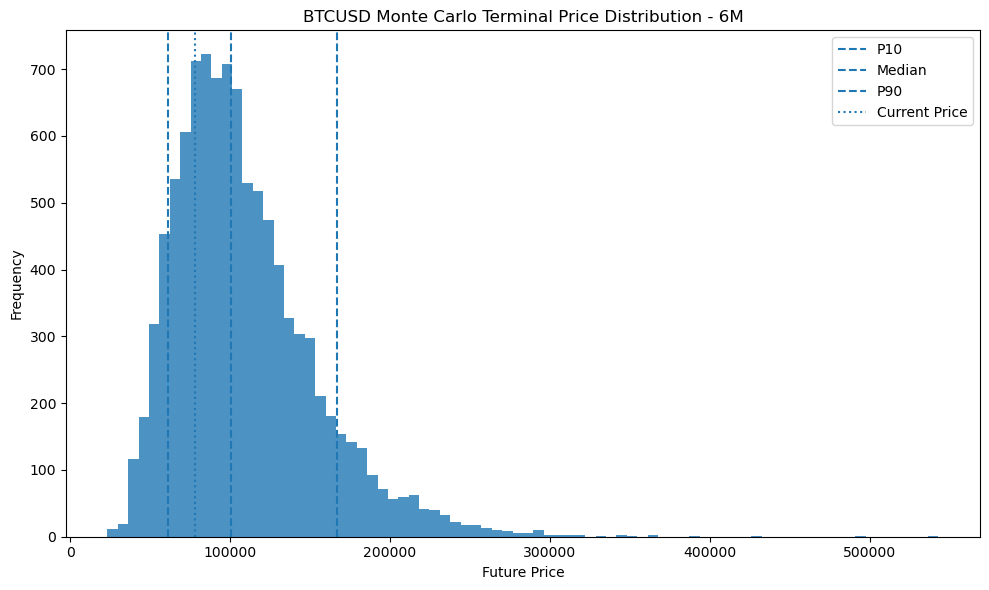

6M completed.

Running 1Y (365 observations)...


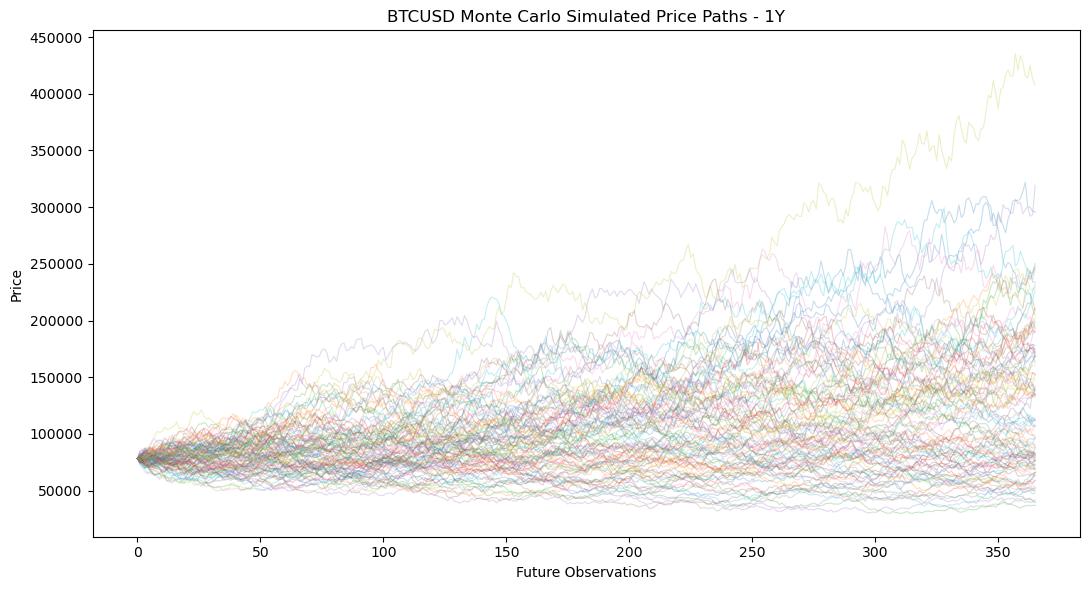

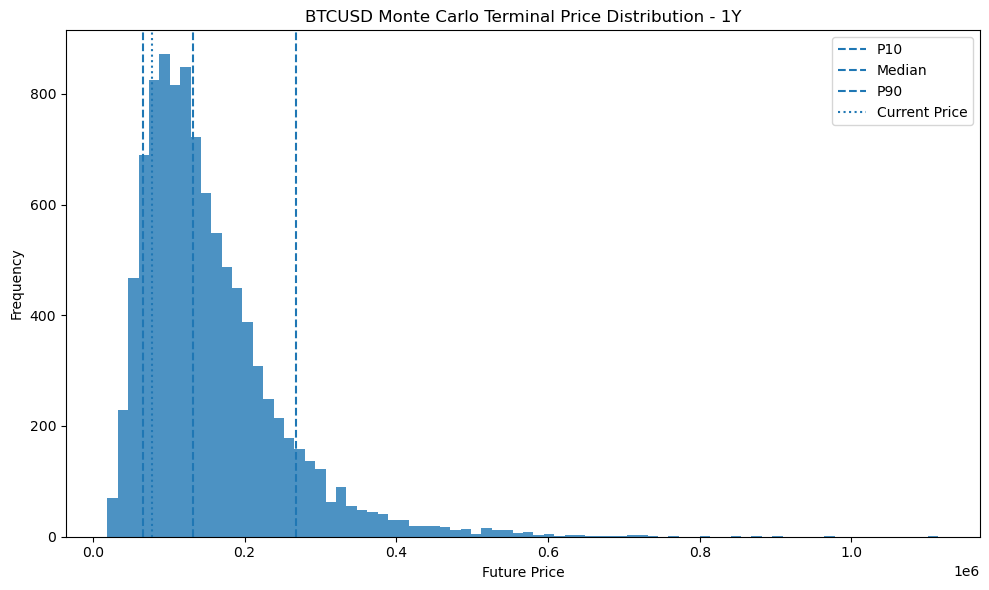

1Y completed.

Running Monte Carlo for ETHUSD
Current Price: 2443.16
Daily Mean Log Return: 0.000357
Daily Volatility: 0.034639
Annualized Volatility: 66.18 %

Running 30D (30 observations)...


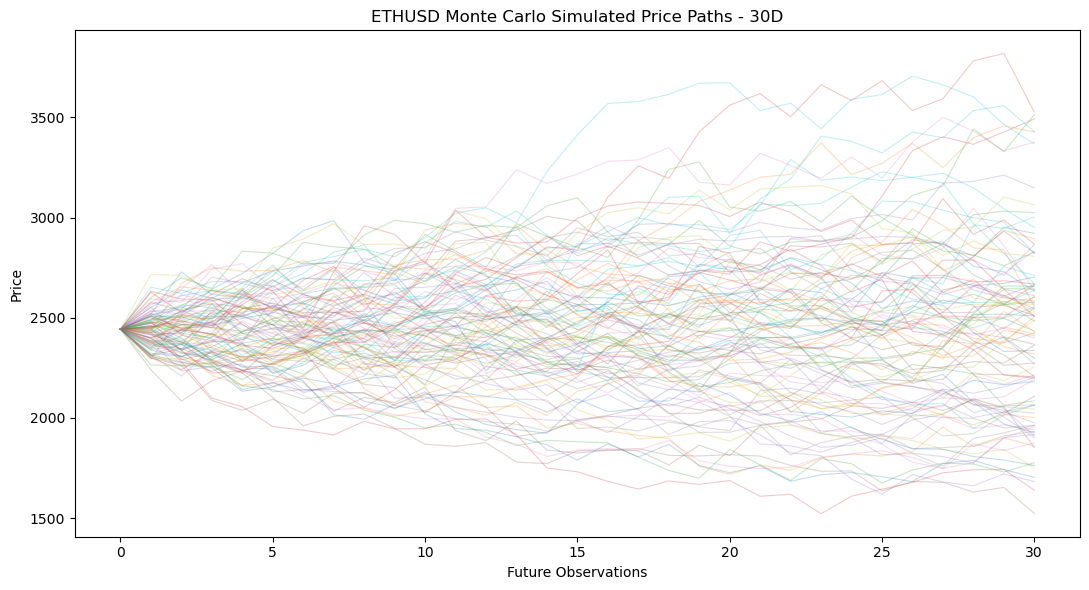

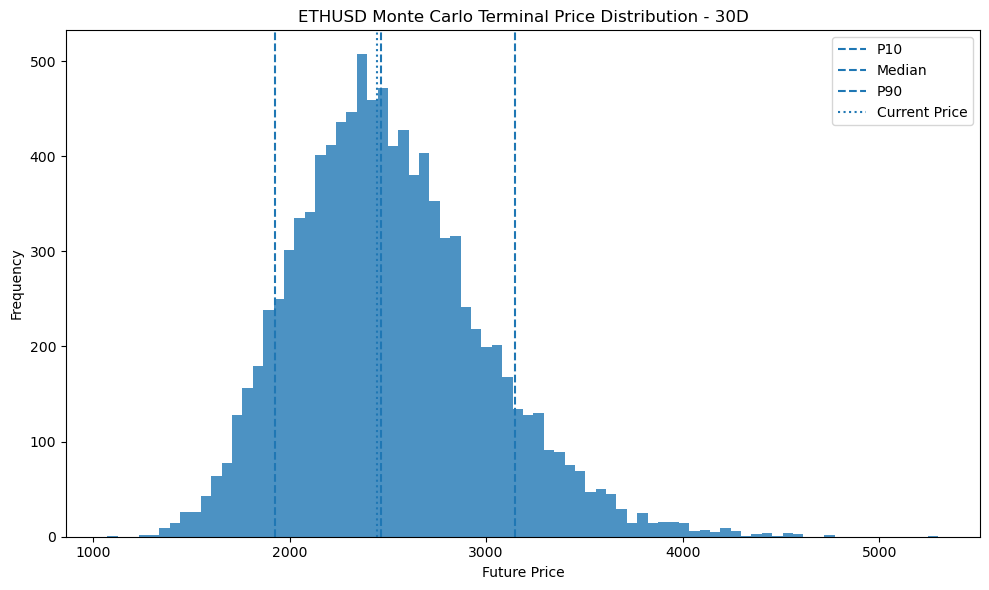

30D completed.

Running 3M (91 observations)...


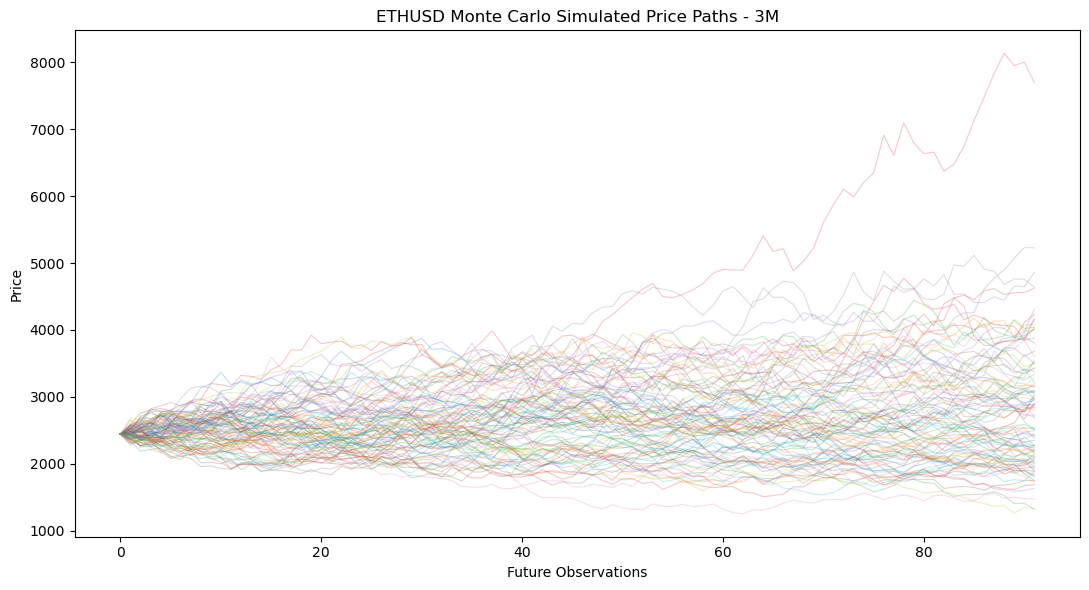

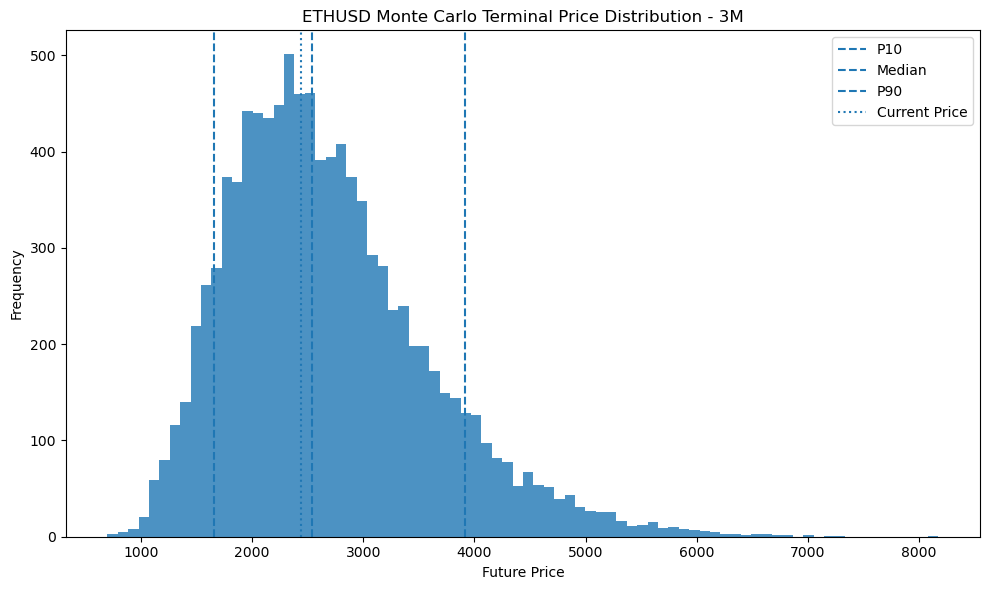

3M completed.

Running 6M (182 observations)...


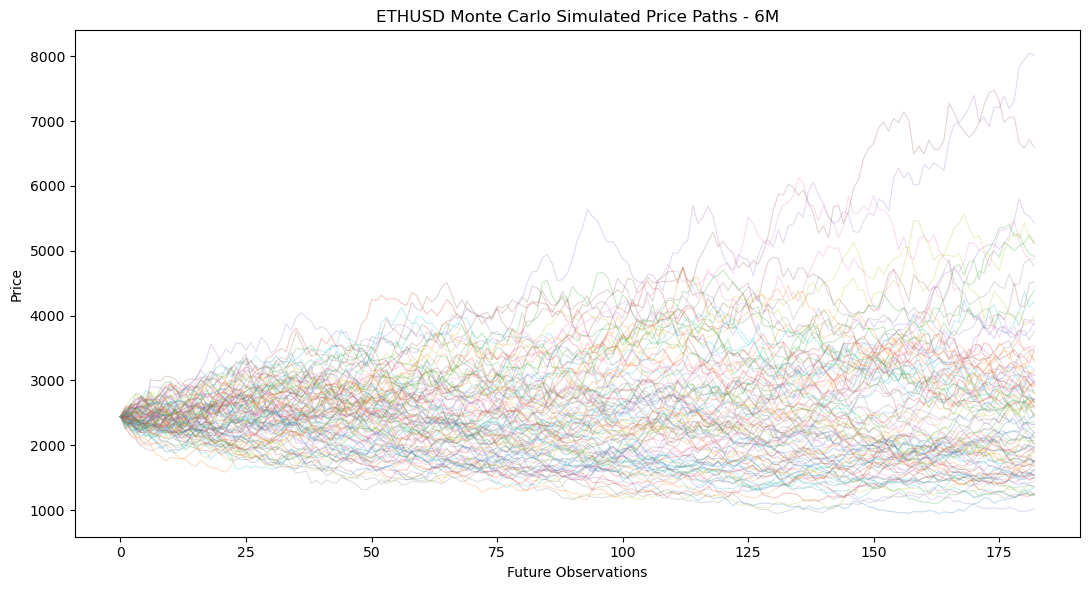

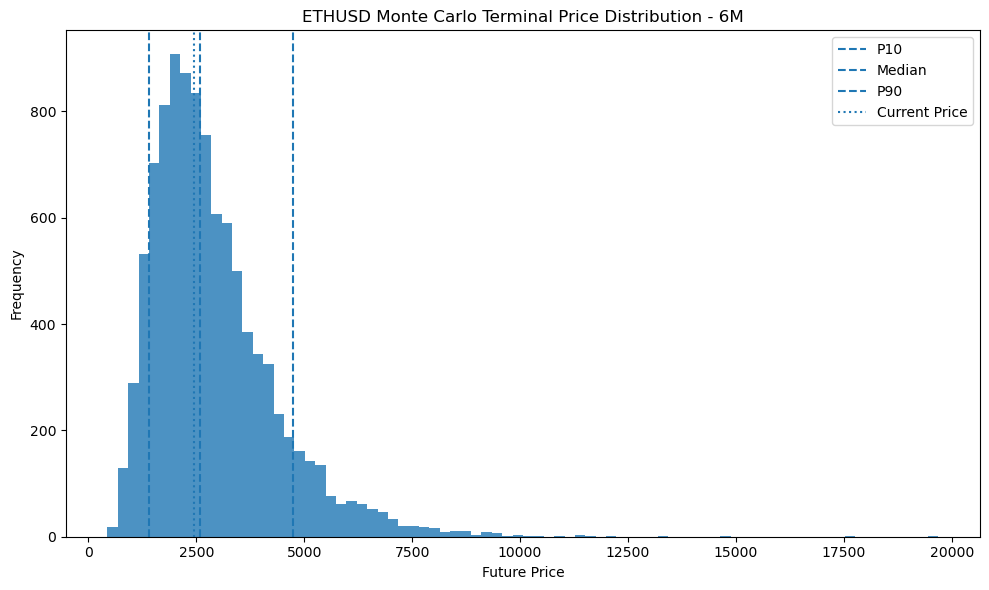

6M completed.

Running 1Y (365 observations)...


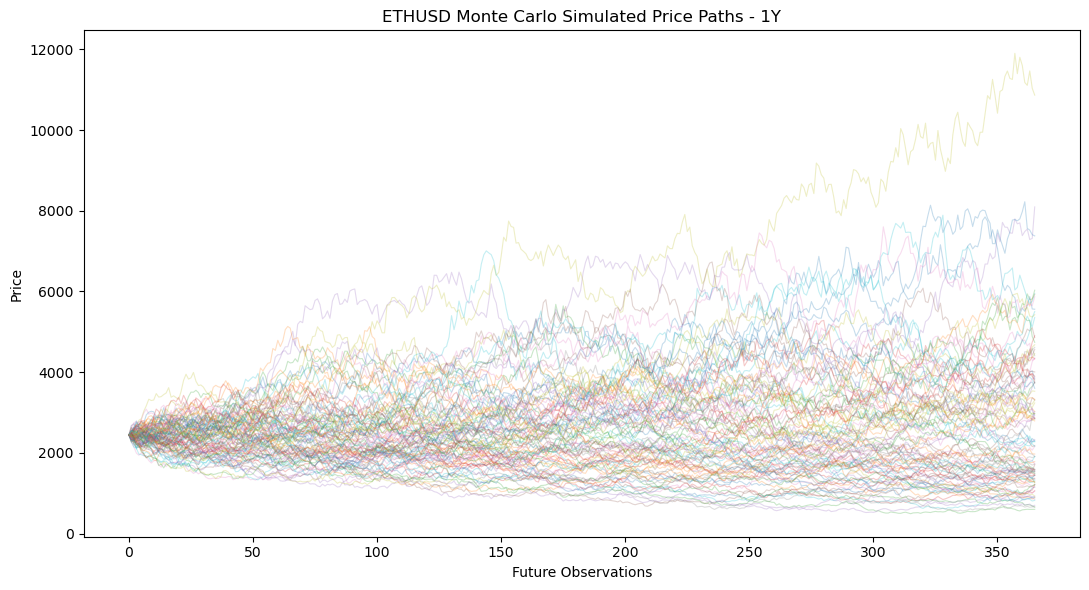

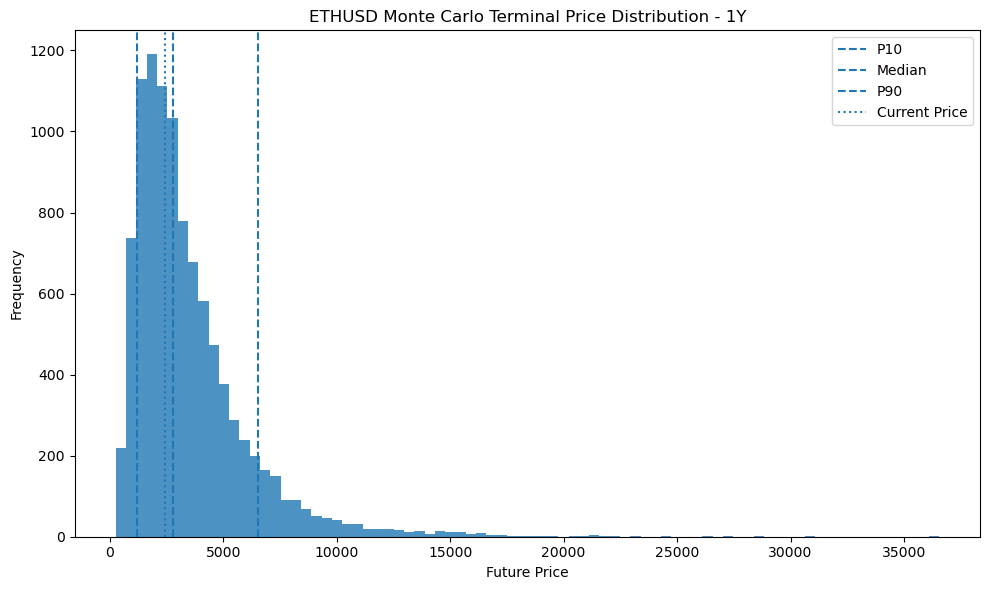

1Y completed.


In [12]:
HORIZONS = [
    "30D",
    "3M",
    "6M",
    "1Y"
]

all_mc_results = []

for asset, config in ASSETS.items():

    result_df = run_monte_carlo_asset(
        asset=asset,
        config=config,
        horizons=HORIZONS,
        n_simulations=N_SIMULATIONS,
        n_sample_paths=N_SAMPLE_PATHS,
        lookback_years=LOOKBACK_YEARS,
        seed=RANDOM_SEED
    )

    all_mc_results.append(
        result_df
    )

In [14]:
mc_summary_raw = pd.concat(
    all_mc_results,
    ignore_index=True
)

mc_summary_raw.head()

,P10_Price,P25_Price,Median_Price,Mean_Price,P75_Price,P90_Price,P10_Return,Median_Return,P90_Return,Probability_Above_Current,...,Horizon,Steps,Current_Price,Mu_Daily,Sigma_Daily,Annualized_Log_Return,Annualized_Volatility,Lookback_Years,Historical_Observations,N_Simulations
0,284.084372,316.052867,353.249987,358.481111,394.760486,438.694863,-0.188910,0.008565,0.252519,0.5235,...,30D,21,350.25,0.000511,0.036561,0.128819,0.580381,3,751,10000
1,250.613793,298.590440,362.930193,379.945121,443.153253,532.238627,-0.284472,0.036203,0.519596,0.5521,...,3M,63,350.25,0.000511,0.036561,0.128819,0.580381,3,751,10000
2,219.671715,282.720547,373.332368,406.582378,493.653246,634.848925,-0.372815,0.065903,0.812559,0.5651,...,6M,126,350.25,0.000511,0.036561,0.128819,0.580381,3,751,10000
3,188.886847,269.300499,395.973774,470.019001,584.268706,841.158762,-0.460709,0.130546,1.401595,0.5868,...,1Y,252,350.25,0.000511,0.036561,0.128819,0.580381,3,751,10000
4,317.698079,336.012427,356.248066,357.741190,377.669948,399.207832,-0.084338,0.026770,0.150587,0.6231,...,30D,21,346.96,0.001313,0.019215,0.330927,0.305035,3,751,10000


In [15]:
mc_summary_display = (
    mc_summary_raw[
        [
            "Asset",
            "Horizon",
            "Current_Price",
            "P10_Price",
            "P25_Price",
            "Median_Price",
            "P75_Price",
            "P90_Price",
            "Median_Return",
            "Probability_Above_Current",
            "Annualized_Volatility"
        ]
    ]
    .copy()
)

In [16]:
price_cols = [
    "Current_Price",
    "P10_Price",
    "P25_Price",
    "Median_Price",
    "P75_Price",
    "P90_Price"
]

for col in price_cols:
    mc_summary_display[col] = (
        mc_summary_display[col]
        .round(2)
    )


mc_summary_display[
    "Median_Return_%"
] = (
    mc_summary_display[
        "Median_Return"
    ]
    * 100
).round(2)


mc_summary_display[
    "Probability_Above_Current_%"
] = (
    mc_summary_display[
        "Probability_Above_Current"
    ]
    * 100
).round(2)


mc_summary_display[
    "Annualized_Volatility_%"
] = (
    mc_summary_display[
        "Annualized_Volatility"
    ]
    * 100
).round(2)

In [17]:
mc_summary_display = (
    mc_summary_display.drop(
        columns=[
            "Median_Return",
            "Probability_Above_Current",
            "Annualized_Volatility"
        ]
    )
)

mc_summary_display

,Asset,Horizon,Current_Price,P10_Price,P25_Price,Median_Price,P75_Price,P90_Price,Median_Return_%,Probability_Above_Current_%,Annualized_Volatility_%
0,TSLA,30D,350.25,284.08,316.05,353.25,394.76,438.69,0.86,52.35,58.04
1,TSLA,3M,350.25,250.61,298.59,362.93,443.15,532.24,3.62,55.21,58.04
2,TSLA,6M,350.25,219.67,282.72,373.33,493.65,634.85,6.59,56.51,58.04
3,TSLA,1Y,350.25,188.89,269.30,395.97,584.27,841.16,13.05,58.68,58.04
4,GOOGL,30D,346.96,317.70,336.01,356.25,377.67,399.21,2.68,62.31,30.50
5,GOOGL,3M,346.96,310.78,340.75,377.55,419.33,461.71,8.82,71.22,30.50
6,GOOGL,6M,346.96,309.71,353.63,409.27,473.99,540.99,17.96,77.72,30.50
7,GOOGL,1Y,346.96,326.32,393.19,481.51,590.74,715.45,38.78,86.16,30.50
8,BTCUSD,30D,78274.20,66434.58,73434.19,81524.96,90493.27,99923.18,4.15,60.83,54.90
9,BTCUSD,3M,78274.20,62965.74,74455.98,89566.47,108108.40,128239.90,14.43,69.25,54.90


In [18]:
raw_output = (
    RESULTS_DIR
    / "Monte_Carlo_summary_raw.csv"
)

display_output = (
    RESULTS_DIR
    / "Monte_Carlo_summary_display.csv"
)


mc_summary_raw.to_csv(
    raw_output,
    index=False
)

mc_summary_display.to_csv(
    display_output,
    index=False
)

print(
    f"Saved: {raw_output}"
)

print(
    f"Saved: {display_output}"
)

Saved: D:\multi-horizon-asset-price-forecasting\results\simulations\Monte_Carlo_summary_raw.csv
Saved: D:\multi-horizon-asset-price-forecasting\results\simulations\Monte_Carlo_summary_display.csv
